### TRANSFER LEARNING

In [6]:
# Import libraries
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader


In [7]:
# Set the path to the project root directory
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "checkpoints"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

METRICS_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "metrics"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

METRICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


In [8]:
# Import project modules
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )

from src.data.dataset import (
    HAM10000Dataset,
    HAM10000_CLASSES,
    CLASS_TO_IDX,
    IDX_TO_CLASS,
)

from src.data.preprocessing import (
    get_eval_transform,
)

from src.data.augmentation import (
    get_train_transform,
)

from src.models.transfer_learning import (
    TransferLearningResNet18,
)


In [9]:
# Reproducibility
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [10]:
# Device
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Using device:",
    device
)

if torch.cuda.is_available():
    print(
        torch.cuda.get_device_name(0)
    )


Using device: cpu


In [11]:
# Load split metadata
train_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "train.csv"
)

val_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "val.csv"
)

test_df = pd.read_csv(
    PROCESSED_DATA_DIR
    / "test.csv"
)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)


Train: 6981
Validation: 1532
Test: 1502


In [12]:
# Transforms
IMAGE_SIZE = 224

train_transform = (
    get_train_transform(
        image_size=IMAGE_SIZE
    )
)

eval_transform = (
    get_eval_transform(
        image_size=IMAGE_SIZE
    )
)


In [13]:
# Dataset
train_dataset = HAM10000Dataset(
    dataframe=train_df,
    project_root=PROJECT_ROOT,
    transform=train_transform,
)

val_dataset = HAM10000Dataset(
    dataframe=val_df,
    project_root=PROJECT_ROOT,
    transform=eval_transform,
)

test_dataset = HAM10000Dataset(
    dataframe=test_df,
    project_root=PROJECT_ROOT,
    transform=eval_transform,
)


In [14]:
# DataLoaders
BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


In [15]:
# Initialize the transfer-learning model
NUM_CLASSES = 7

model = TransferLearningResNet18(
    num_classes=NUM_CLASSES,
    dropout=0.3,
    pretrained=True,
    freeze_backbone=True,
)

model = model.to(
    device
)

print(model)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\ADMIN/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:30<00:00, 1.55MB/s]


TransferLearningResNet18(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(

In [16]:
# Check model output
images, labels = next(
    iter(train_loader)
)

images = images.to(
    device
)

with torch.no_grad():
    outputs = model(
        images
    )

print(
    "Input shape:",
    images.shape
)

print(
    "Output shape:",
    outputs.shape
)


Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 7])


In [17]:
# Check model output
images, labels = next(
    iter(train_loader)
)

images = images.to(
    device
)

with torch.no_grad():
    outputs = model(
        images
    )

print(
    "Input shape:",
    images.shape
)

print(
    "Output shape:",
    outputs.shape
)


Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 7])


In [18]:
# Count model parameters
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_params = (
    total_params
    - trainable_params
)

print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)

print(
    f"Frozen parameters: "
    f"{frozen_params:,}"
)


Total parameters: 11,180,103
Trainable parameters: 3,591
Frozen parameters: 11,176,512


In [19]:
# Verify which parameters are trainable
for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        print(name)


backbone.fc.1.weight
backbone.fc.1.bias


In [20]:
# Import training modules
from src.training.losses import (
    compute_class_weights,
    get_weighted_cross_entropy_loss,
)

from src.training.train import (
    fit,
)


In [21]:
# Class weights for imbalanced dataset
class_weights = compute_class_weights(
    train_df=train_df,
    class_names=HAM10000_CLASSES,
    device=device,
)

criterion = get_weighted_cross_entropy_loss(
    class_weights
)

print(class_weights)
print(criterion)


tensor([ 4.4923,  2.7626,  1.2918, 14.0463,  1.2901,  0.2130, 10.0736])
CrossEntropyLoss()


In [22]:
# Optimizer
# Only parameters with requires_grad=True are optimized.
optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=0.001,
    weight_decay=1e-4,
)


In [23]:
# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)


In [24]:
# Train transfer-learning model
history_df = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=20,
    checkpoint_path=(
        CHECKPOINT_DIR
        / "transfer_resnet18_best.pt"
    ),
    scheduler=scheduler,
    early_stopping_patience=5,
    history_path=(
        METRICS_DIR
        / "transfer_resnet18_training_history.csv"
    ),
)


Epoch 01/20 | Train Loss: 1.7318 | Train Acc: 0.4661 | Val Loss: 1.1983 | Val Acc: 0.5607 | LR: 0.001000
  -> Best model saved.
Epoch 02/20 | Train Loss: 1.4647 | Train Acc: 0.5617 | Val Loss: 1.3580 | Val Acc: 0.5170 | LR: 0.001000
Epoch 03/20 | Train Loss: 1.3652 | Train Acc: 0.5650 | Val Loss: 1.0811 | Val Acc: 0.6070 | LR: 0.001000
  -> Best model saved.
Epoch 04/20 | Train Loss: 1.2856 | Train Acc: 0.5800 | Val Loss: 1.2959 | Val Acc: 0.5470 | LR: 0.001000
Epoch 05/20 | Train Loss: 1.2613 | Train Acc: 0.5813 | Val Loss: 1.0936 | Val Acc: 0.5809 | LR: 0.001000
Epoch 06/20 | Train Loss: 1.2684 | Train Acc: 0.5724 | Val Loss: 1.0021 | Val Acc: 0.6338 | LR: 0.001000
  -> Best model saved.
Epoch 07/20 | Train Loss: 1.2584 | Train Acc: 0.5876 | Val Loss: 1.3312 | Val Acc: 0.5104 | LR: 0.001000
Epoch 08/20 | Train Loss: 1.2134 | Train Acc: 0.5862 | Val Loss: 1.0746 | Val Acc: 0.6188 | LR: 0.001000
Epoch 09/20 | Train Loss: 1.2069 | Train Acc: 0.5864 | Val Loss: 1.1536 | Val Acc: 0.5718 |

In [25]:
history_df.head()

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate
0,1,1.731819,0.466122,1.198328,0.560705,0.001
1,2,1.464728,0.561667,1.358046,0.516971,0.001
2,3,1.365153,0.564962,1.081135,0.607050,0.001
3,4,1.285646,0.580003,1.295894,0.546997,0.001
4,5,1.261337,0.581292,1.093590,0.580940,0.001


In [26]:
# Load best model
model.load_state_dict(
    torch.load(
        CHECKPOINT_DIR
        / "transfer_resnet18_best.pt",
        map_location=device,
    )
)

print("Best Transfer Learning ResNet18 model loaded.")


Best Transfer Learning ResNet18 model loaded.


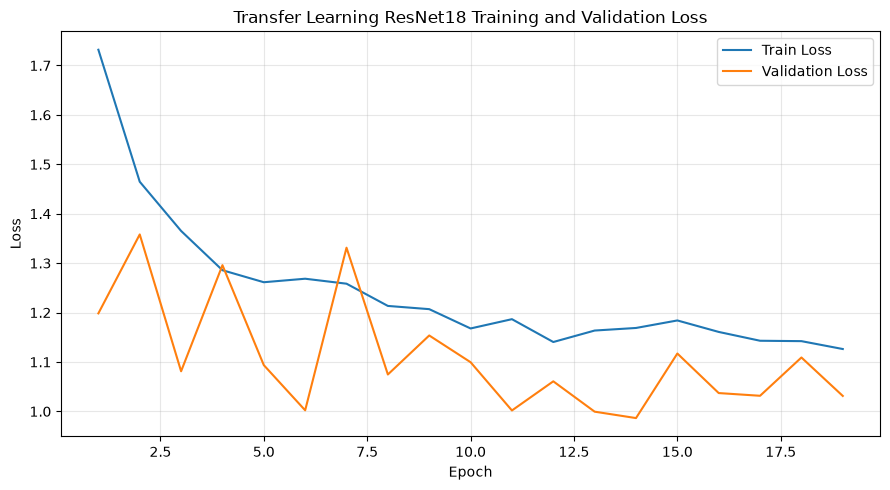

In [27]:
# Plot loss
plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss",
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning ResNet18 Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "transfer_resnet18_loss_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


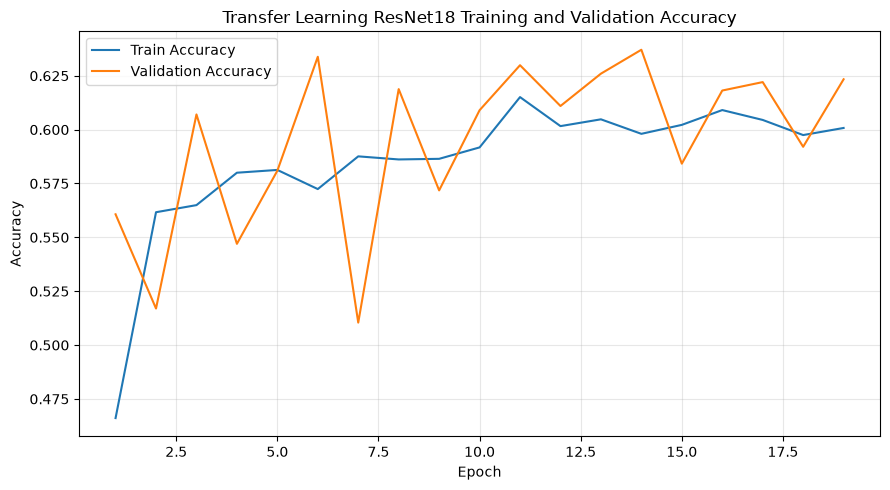

In [28]:
# Plot accuracy
plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train Accuracy",
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning ResNet18 Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "transfer_resnet18_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
